***Important libraries imported***

In [155]:
import pandas as pd
import folium
import matplotlib.pyplot as plt
import seaborn as sns

***Bubble Map for Road Accidents in Nepal***

In [156]:
from folium.plugins import MarkerCluster

data = pd.read_csv("Data/Nepal_RoadAccidents_Cleaned.csv")

map_center = [data['Latitude'].mean(), data['Longitude'].mean()]
m = folium.Map(location=map_center, zoom_start=7)

marker_cluster = MarkerCluster().add_to(m)

for _, row in data.iterrows():

    if row['Fatalities'] > 2:
        color = "red"
    elif row['Fatalities'] > 0:
        color = "orange"
    else:
        color = "green"

    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=5,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.6,
        popup=f"Fatalities: {row['Fatalities']}"
    ).add_to(marker_cluster)

m.save("Fig/accident_severity_bubble_map.html")

***Victim Demographic Analysis***

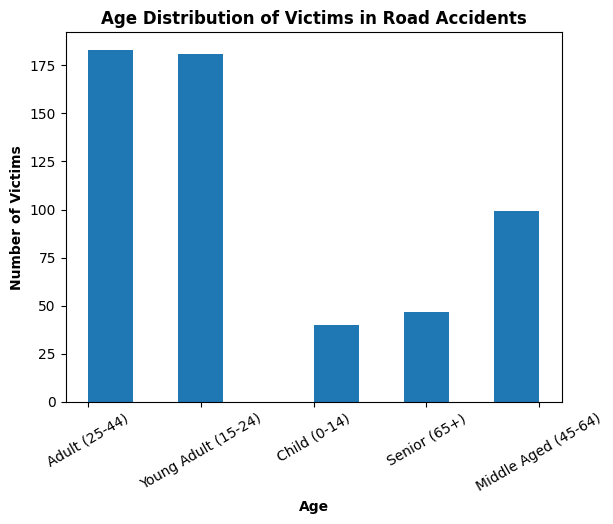

In [157]:
# Age Distribution
data['Victim_Age_Group'].hist(bins = 10)
plt.xticks(rotation=30)
plt.title("Age Distribution of Victims in Road Accidents", fontweight='bold')
plt.xlabel("Age", fontweight='bold')
plt.grid(False)
plt.ylabel("Number of Victims", fontweight='bold')
plt.show()

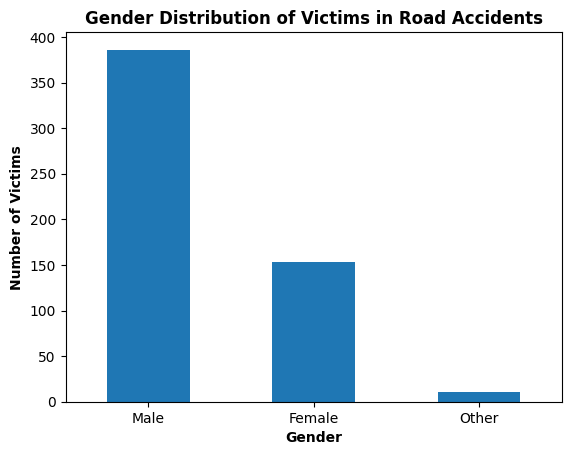

In [158]:
# Gender Distribution
data['Victim_Gender'].value_counts().plot(kind='bar')
plt.title("Gender Distribution of Victims in Road Accidents", fontweight='bold')
plt.xlabel("Gender", fontweight='bold')
plt.ylabel("Number of Victims", fontweight='bold')
plt.xticks(rotation=0)
plt.show()

***Temporal Analysis***

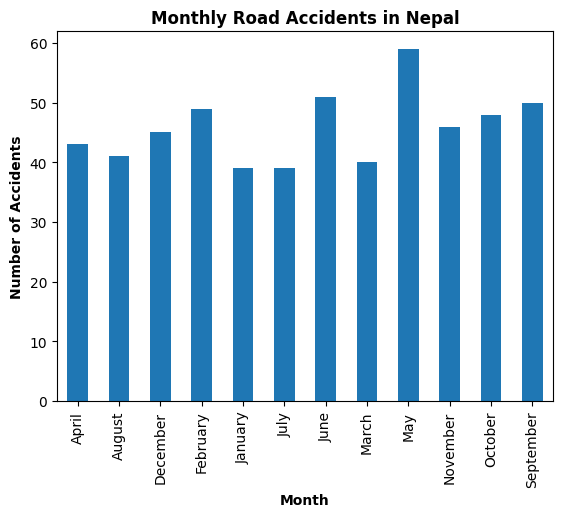

In [159]:
monthly_counts = data['Month_Name'].value_counts().sort_index()

monthly_counts.plot(kind='bar')

plt.title("Monthly Road Accidents in Nepal", fontweight='bold')
plt.xlabel("Month", fontweight='bold')
plt.ylabel("Number of Accidents", fontweight='bold')

plt.show()

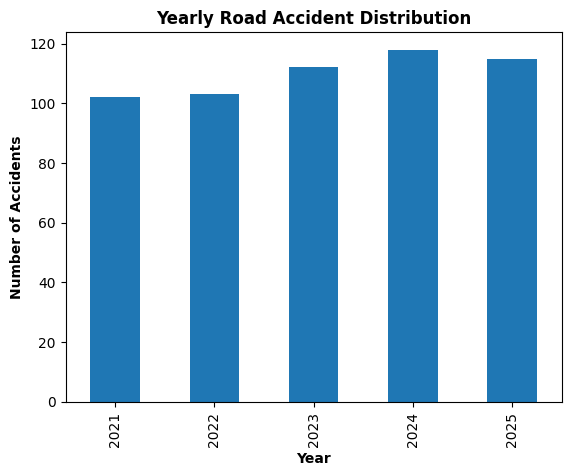

In [160]:
# Yearly Trend
yearly_counts = data['Year'].value_counts().sort_index()
yearly_counts.plot(kind='bar')

plt.title("Yearly Road Accident Distribution", fontweight='bold')
plt.xlabel("Year", fontweight='bold')
plt.ylabel("Number of Accidents", fontweight='bold')

plt.show()

***Correlation Heatmap***

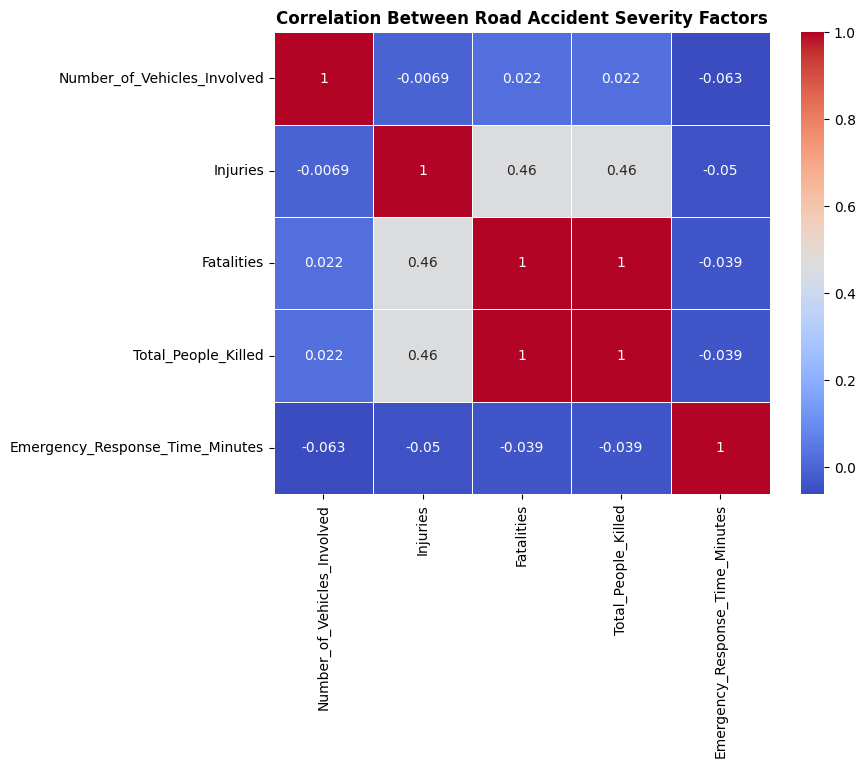

In [161]:
features = data[[
    'Number_of_Vehicles_Involved',
    'Injuries',
    'Fatalities',
    'Total_People_Killed',
    'Emergency_Response_Time_Minutes'
]]

corr = features.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)

plt.title("Correlation Between Road Accident Severity Factors", fontweight='bold')
plt.show()